# Per-residue recovery — un-blending the average against native RMSF

Averaged `toGIG` is a mean over 10 positions, so it **blends the part of the peptide that is identical
between registers with the part that *is* the register**. The shared N-terminus dilutes the anchor
signal: a design can score a middling average while being right where it matters (the anchor) or wrong
where it matters. Per-residue un-blends it — but only if each position is judged against **its own**
native tolerance, because some residues barely move in the real peptide (tight band, must be matched)
while others are floppy even natively (deviation there is meaningless).

The tolerance is the **per-residue RMSF from the 300 K native MD** we already ran. Score each design
position against its native band and two things the average hid become visible: **where** a near-miss
goes wrong (the register localizes to the C-terminal anchor), and **which failure mode** a design is in
(de-novo blows out the C-terminus; seeded designs are frozen — too still — everywhere).

In [1]:
import os, sys, glob, re, warnings; warnings.filterwarnings("ignore")
sys.path.insert(0, "/home/ubuntu/if-mhc/py")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import score_denovo_designs as S
import native_md_components as NM
plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
ROOT = S.ROOT; POS = np.arange(1, 11)

def frame_pa(model):
    '''MD frame -> (10,3) peptide Cα in the committor frame (same superposition as S.score_occ).'''
    ms_start, ms = model.chain_seqs["mhc"]
    mca = np.array([model.ca[ms_start + i] for i in range(len(ms))])
    m = ms.find(S.MHC_MOTIF); loc = list(range(m, min(m + 179, len(ms))))
    k = S._offset("".join(ms[i] for i in loc), S.REFSEQ)
    idx = [j for j, i in enumerate(loc) if 0 <= j + k < len(S.REF_CA)]
    if len(idx) < 50: return None
    R, t = S._robust(mca[[loc[j] for j in idx]], S.REF_CA[[j + k for j in idx]])
    ps, _ = model.chain_seqs["pep"]
    return np.array([model.ca[ps + i] for i in range(10)]) @ R + t

def design_pa(path):
    '''Design PDB -> (10,3) peptide Cα in the committor frame, or None.'''
    r = S._map_peptide(path)
    return None if (r is None or r[0] is None) else r[0]
print("ready")

ready


## 1 · Native per-residue tolerance (300 K RMSF)

For each native trajectory, superpose every frame on the groove and collect the peptide Cα. Per
position: the mean native location `mu`, the **RMSF** (3-D positional fluctuation about that mean), and
the **P95** deviation (95 % of native frames sit within this of the mean) — the empirical tolerance
band. Anchors buried in pockets should be tight; the solvent-exposed central bulge should be loose.

In [2]:
REF = {}
for pid, job in [("6AM5", "ifmhc_6AM5_md_300K"), ("6AMU", "ifmhc_6AMU_md_300K")]:
    models, _ = NM.load_md(job, 250)
    P = np.array([p for p in (frame_pa(m) for m in models) if p is not None])   # (F,10,3)
    mu = P.mean(0)
    dev = np.sqrt(((P - mu) ** 2).sum(-1))                                       # (F,10) per-frame dev
    REF[pid] = dict(mu=mu, rmsf=np.sqrt((dev ** 2).mean(0)), p95=np.percentile(dev, 95, axis=0), n=len(P))
tol = pd.DataFrame({"pos": POS,
    "GIG_RMSF": REF["6AM5"]["rmsf"].round(2), "GIG_P95": REF["6AM5"]["p95"].round(2),
    "DRG_RMSF": REF["6AMU"]["rmsf"].round(2), "DRG_P95": REF["6AMU"]["p95"].round(2)})
display(tol)

,pos,GIG_RMSF,GIG_P95,DRG_RMSF,DRG_P95
0,1,0.51,0.84,0.38,0.62
1,2,0.38,0.58,0.43,0.69
2,3,0.38,0.63,0.38,0.63
3,4,0.50,0.84,0.43,0.67
4,5,0.44,0.68,0.42,0.67
5,6,0.76,1.34,0.50,0.84
6,7,0.49,0.78,0.59,1.00
7,8,0.42,0.67,0.58,0.98
8,9,0.39,0.62,0.67,1.10
9,10,0.37,0.60,0.78,1.32


## 2 · The register, made visible per position

Between-register separation at each position is `|mu_GIG − mu_DRG|`. Divided by the native RMSF it
becomes a **per-residue z-score**: how many native fluctuation-widths apart the two registers sit at
that residue. Where z ≈ 1 the registers are indistinguishable within thermal noise (register-neutral);
where z ≫ 1 the position **is** the register. This is the anchor signal the averaged toGIG buried.

saved perres_register_visible.png


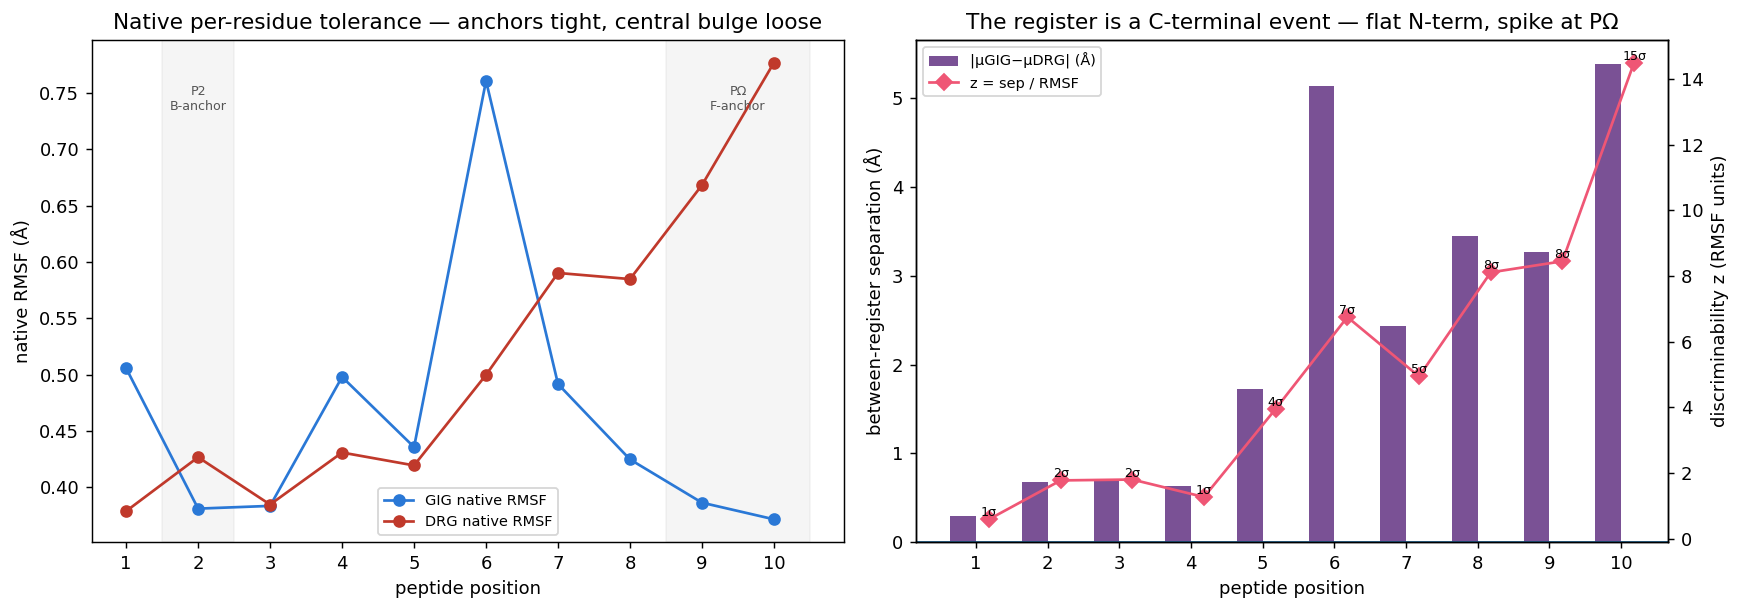

z per position: {1: 0.6, 2: 1.8, 3: 1.8, 4: 1.3, 5: 4.0, 6: 6.8, 7: 4.9, 8: 8.1, 9: 8.5, 10: 14.5}


In [3]:
sep = np.linalg.norm(REF["6AM5"]["mu"] - REF["6AMU"]["mu"], axis=1)
z = sep / np.maximum(REF["6AM5"]["rmsf"], 1e-6)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.8))
# left: native RMSF bands
a1.plot(POS, REF["6AM5"]["rmsf"], "-o", color="#2a78d6", label="GIG native RMSF")
a1.plot(POS, REF["6AMU"]["rmsf"], "-o", color="#c0392b", label="DRG native RMSF")
a1.axvspan(1.5, 2.5, color="#888", alpha=.08); a1.axvspan(8.5, 10.5, color="#888", alpha=.08)
a1.text(2, a1.get_ylim()[1]*.95, "P2\nB-anchor", ha="center", va="top", fontsize=7, color="#555")
a1.text(9.5, a1.get_ylim()[1]*.95, "PΩ\nF-anchor", ha="center", va="top", fontsize=7, color="#555")
a1.set_xticks(POS); a1.set_xlabel("peptide position"); a1.set_ylabel("native RMSF (Å)")
a1.set_title("Native per-residue tolerance — anchors tight, central bulge loose"); a1.legend(fontsize=8)
# right: separation & z
a2.bar(POS - 0.18, sep, 0.36, color="#7a5195", label="|μGIG−μDRG| (Å)")
a2b = a2.twinx(); a2b.plot(POS + 0.18, z, "-D", color="#ef5675", label="z = sep / RMSF")
a2.axhline(0); a2.set_xticks(POS); a2.set_xlabel("peptide position")
a2.set_ylabel("between-register separation (Å)"); a2b.set_ylabel("discriminability z (RMSF units)")
a2.set_title("The register is a C-terminal event — flat N-term, spike at PΩ")
for x_, zz in zip(POS, z): a2b.annotate(f"{zz:.0f}σ", (x_ + 0.18, zz), fontsize=7, ha="center", va="bottom")
l1, la = a2.get_legend_handles_labels(); l2, lb = a2b.get_legend_handles_labels(); a2.legend(l1+l2, la+lb, fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig(f"{ROOT}/figures/perres_register_visible.png", dpi=150)
print("saved perres_register_visible.png"); plt.show()
print("z per position:", dict(zip(POS.tolist(), z.round(1).tolist())))

## 3 · Score designs per position against their native band

For every design, per-residue deviation from its **cognate** native mean (`|pa − mu_cognate|`), pooled
per position against the native P95 band. The native band is thermal-**tight** (~0.6–1.3 Å), so this is
a stringent ruler. Two things to read off: the *shape* of the de-novo deviation profile (where the miss
concentrates) and the *in-band fraction* (does anything reach native precision anywhere).

de-novo designs scored per-residue: 1288  (771 GIG, 517 DRG)
threading breakdown: {'reverse': 643, 'forward': 591, 'ambiguous': 54}


saved perres_design_deviation.png


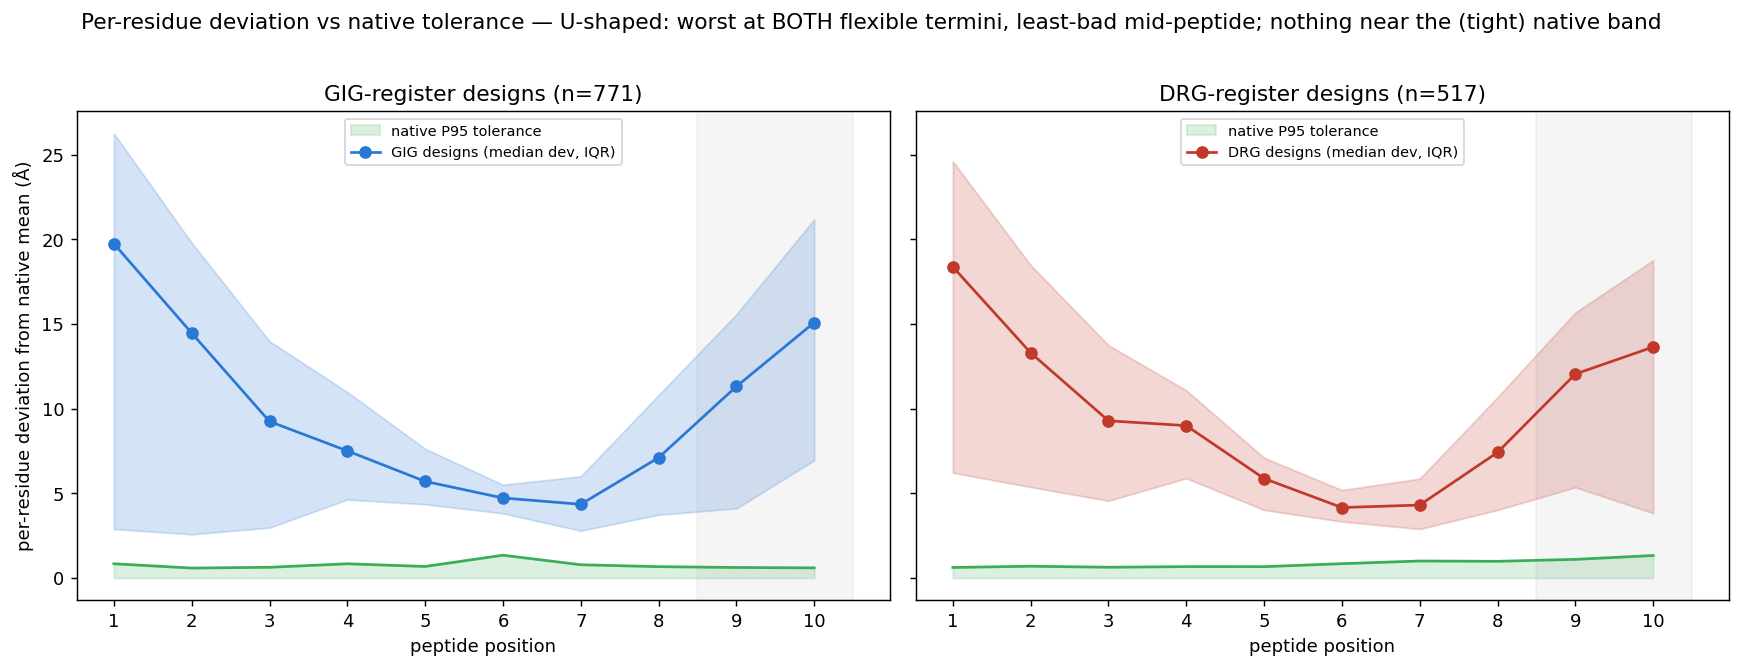

in-band fraction per position (dev <= native P95):
        P1    P2    P3   P4   P5    P6    P7    P8    P9  P10
6AM5  0.02  0.01  0.01  0.0  0.0  0.01  0.01  0.00  0.00  0.0
6AMU  0.01  0.01  0.00  0.0  0.0  0.01  0.01  0.01  0.02  0.0


In [4]:
def load_designs():
    rows = []
    for f in S.gather([f"{ROOT}/outputs/{x}/pdb" for x in ("grind","ladder","promising","rfd_denovo30","rfd_maxcond")]):
        pa = design_pa(f)
        if pa is None: continue
        m = S.parse_meta(f); mu = REF["6AM5"]["mu"] if m["pid"] == "6AM5" else REF["6AMU"]["mu"]
        dev = np.linalg.norm(pa - mu, axis=1)
        thr = S.occupancy(pa)["threading"]
        rows.append(dict(source=m["source"], pid=m["pid"], threading=thr, **{f"d{p}": float(dev[p-1]) for p in POS}))
    return pd.DataFrame(rows)
DES = load_designs()
print(f"de-novo designs scored per-residue: {len(DES)}  ({(DES.pid=='6AM5').sum()} GIG, {(DES.pid=='6AMU').sum()} DRG)")
print("threading breakdown:", DES.threading.value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), sharey=True)
for ax, pid, name, col in [(axes[0], "6AM5", "GIG", "#2a78d6"), (axes[1], "6AMU", "DRG", "#c0392b")]:
    sub = DES[DES.pid == pid]; band = REF[pid]["p95"]
    dmat = sub[[f"d{p}" for p in POS]].values                       # (n,10)
    med = np.median(dmat, 0); q1 = np.percentile(dmat, 25, 0); q3 = np.percentile(dmat, 75, 0)
    ax.fill_between(POS, 0, band, color="#3aae57", alpha=.18, label="native P95 tolerance")
    ax.plot(POS, band, color="#3aae57", lw=1.5)
    ax.fill_between(POS, q1, q3, color=col, alpha=.2)
    ax.plot(POS, med, "-o", color=col, label=f"{name} designs (median dev, IQR)")
    ax.axvspan(8.5, 10.5, color="#888", alpha=.08)
    ax.set_xticks(POS); ax.set_xlabel("peptide position"); ax.set_title(f"{name}-register designs (n={len(sub)})")
    ax.legend(fontsize=8)
axes[0].set_ylabel("per-residue deviation from native mean (Å)")
fig.suptitle("Per-residue deviation vs native tolerance — U-shaped: worst at BOTH flexible termini, "
             "least-bad mid-peptide; nothing near the (tight) native band", y=1.02)
plt.tight_layout(); plt.savefig(f"{ROOT}/figures/perres_design_deviation.png", dpi=150, bbox_inches="tight")
print("saved perres_design_deviation.png"); plt.show()

# quantitative: fraction of designs in-band per position (dev <= native P95)
inb = {}
for pid in ["6AM5", "6AMU"]:
    sub = DES[DES.pid == pid]; band = REF[pid]["p95"]
    inb[pid] = [(sub[f"d{p}"] <= band[p-1]).mean().round(2) for p in POS]
print("in-band fraction per position (dev <= native P95):")
print(pd.DataFrame(inb, index=[f"P{p}" for p in POS]).T)

### 3b · Is the U-shape a real global failure, or a forward/reverse-threading averaging artifact?

A structurally distinct population was found late in this project: with nothing constraining peptide
N->C direction, unconditioned RFdiffusion buries either its C-terminal anchor (**forward** — like both
native registers) or its N-terminal anchor (**reverse** — a mirror-image threading) at roughly 50/50
odds. Averaging both into one deviation profile could manufacture a spurious U-shape (forward designs
bad at the N-term, reverse designs bad at the C-term, "average" bad at both). Re-plot split by
`threading` to check whether the U-shape survives within EACH population alone.

saved figures/perres_by_threading.png


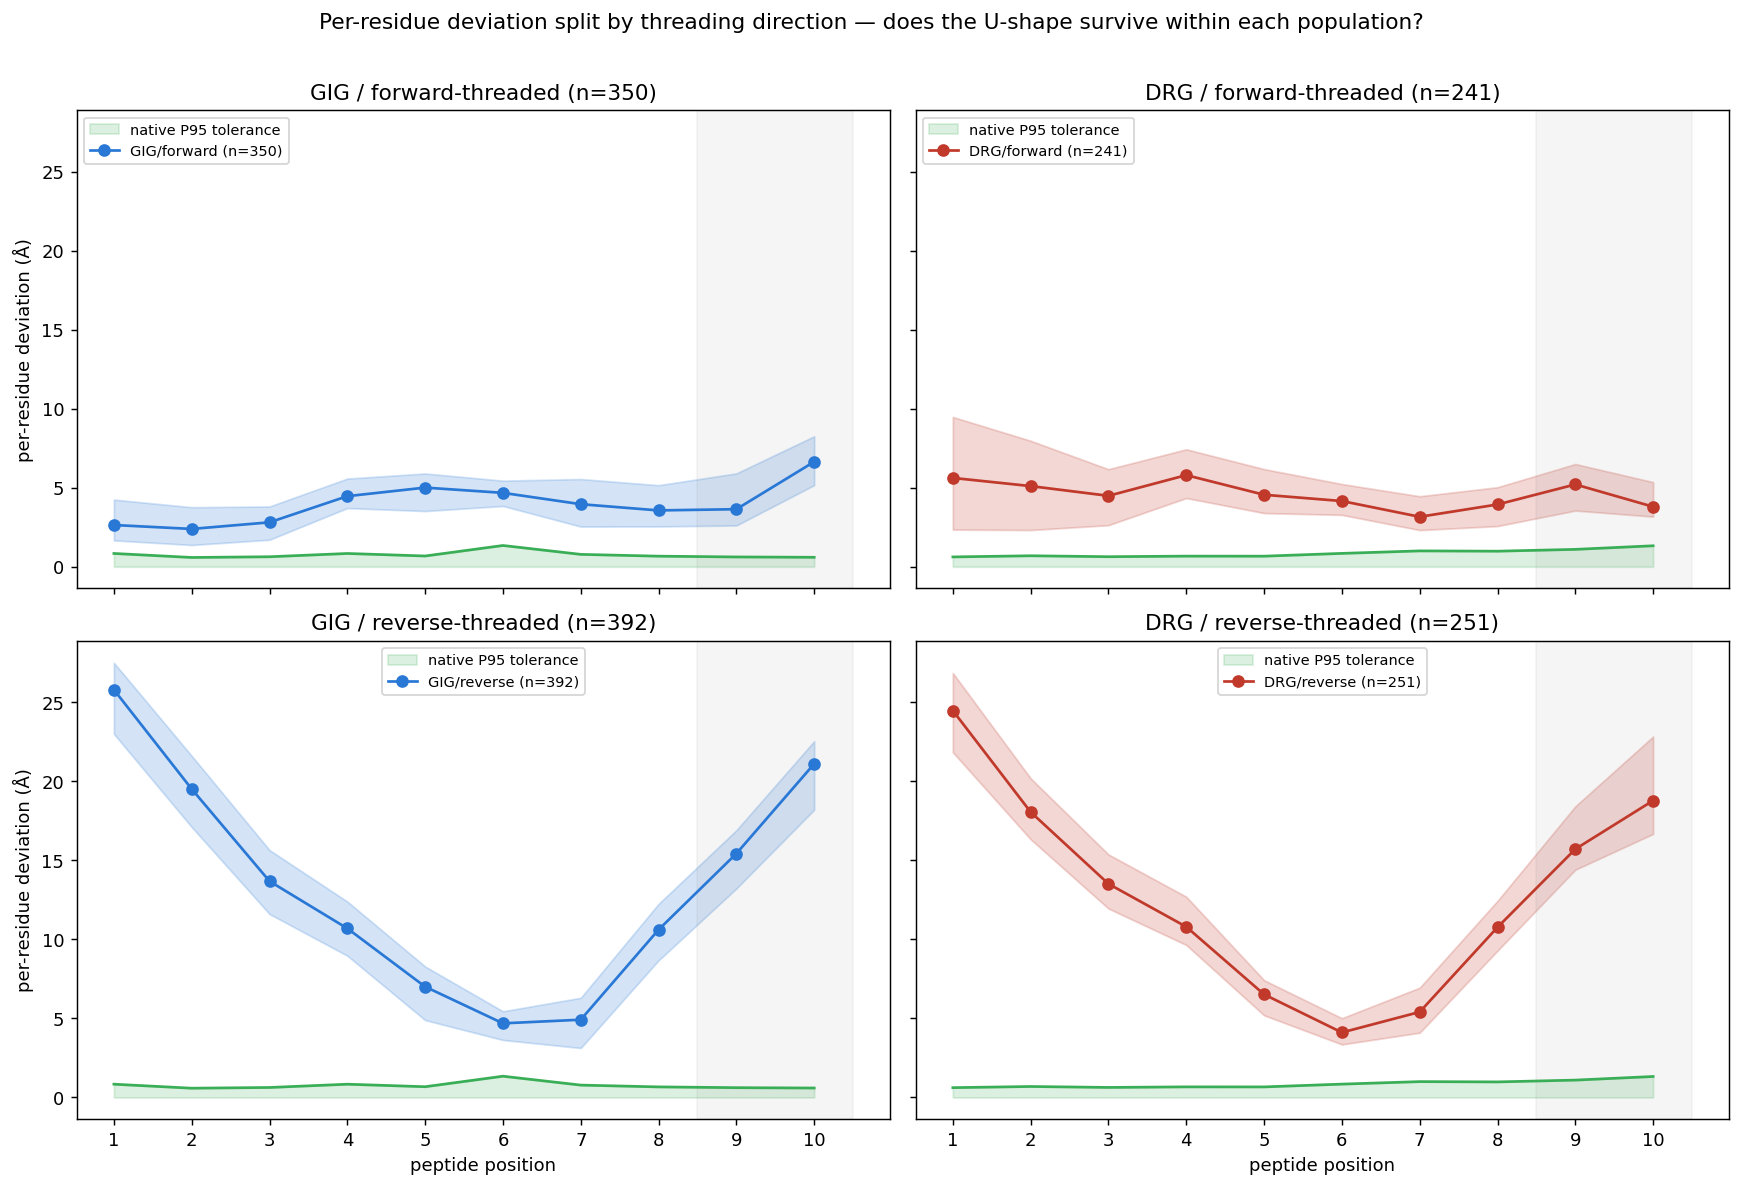

If BOTH forward and reverse panels are still U-shaped (not just monotonic-worse-at-one-end),
the U-shape is a real global failure, not a threading-averaging artifact.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9), sharey=True, sharex=True)
for row, thr in enumerate(["forward", "reverse"]):
    for col, (pid, name, colr) in enumerate([("6AM5", "GIG", "#2a78d6"), ("6AMU", "DRG", "#c0392b")]):
        ax = axes[row][col]
        sub = DES[(DES.pid == pid) & (DES.threading == thr)]; band = REF[pid]["p95"]
        if len(sub) == 0:
            ax.set_title(f"{name} / {thr} (n=0)"); continue
        dmat = sub[[f"d{p}" for p in POS]].values
        med = np.median(dmat, 0); q1 = np.percentile(dmat, 25, 0); q3 = np.percentile(dmat, 75, 0)
        ax.fill_between(POS, 0, band, color="#3aae57", alpha=.18, label="native P95 tolerance")
        ax.plot(POS, band, color="#3aae57", lw=1.5)
        ax.fill_between(POS, q1, q3, color=colr, alpha=.2)
        ax.plot(POS, med, "-o", color=colr, label=f"{name}/{thr} (n={len(sub)})")
        ax.axvspan(8.5, 10.5, color="#888", alpha=.08)
        ax.set_xticks(POS); ax.legend(fontsize=8); ax.set_title(f"{name} / {thr}-threaded (n={len(sub)})")
    axes[row][0].set_ylabel("per-residue deviation (Å)")
for ax in axes[1]: ax.set_xlabel("peptide position")
fig.suptitle("Per-residue deviation split by threading direction — does the U-shape survive within each population?", y=1.01)
plt.tight_layout(); plt.savefig(f"{ROOT}/figures/perres_by_threading.png", dpi=150, bbox_inches="tight")
print("saved figures/perres_by_threading.png"); plt.show()
print("If BOTH forward and reverse panels are still U-shaped (not just monotonic-worse-at-one-end),")
print("the U-shape is a real global failure, not a threading-averaging artifact.")

## 4 · Two failure modes the average reports identically

The averaged number gives a seeded design and a de-novo design the same middling score for opposite
reasons. Per-residue tells them apart:
- **de-novo** — misses native tolerance at *every* position (5–30× the band), worst at both flexible
  termini (§3): *far everywhere, and not even placed at the ends* — a global placement failure, not a
  register-specific one.
- **seeded** — sits *at* the native tolerance in deviation (near-native everywhere) but is **too
  rigid**: its ensemble RMSF collapses below the native band at every position: *frozen everywhere*. We
  compute the seed-echo ensemble's own per-residue RMSF and compare it to native.

saved perres_failure_modes.png


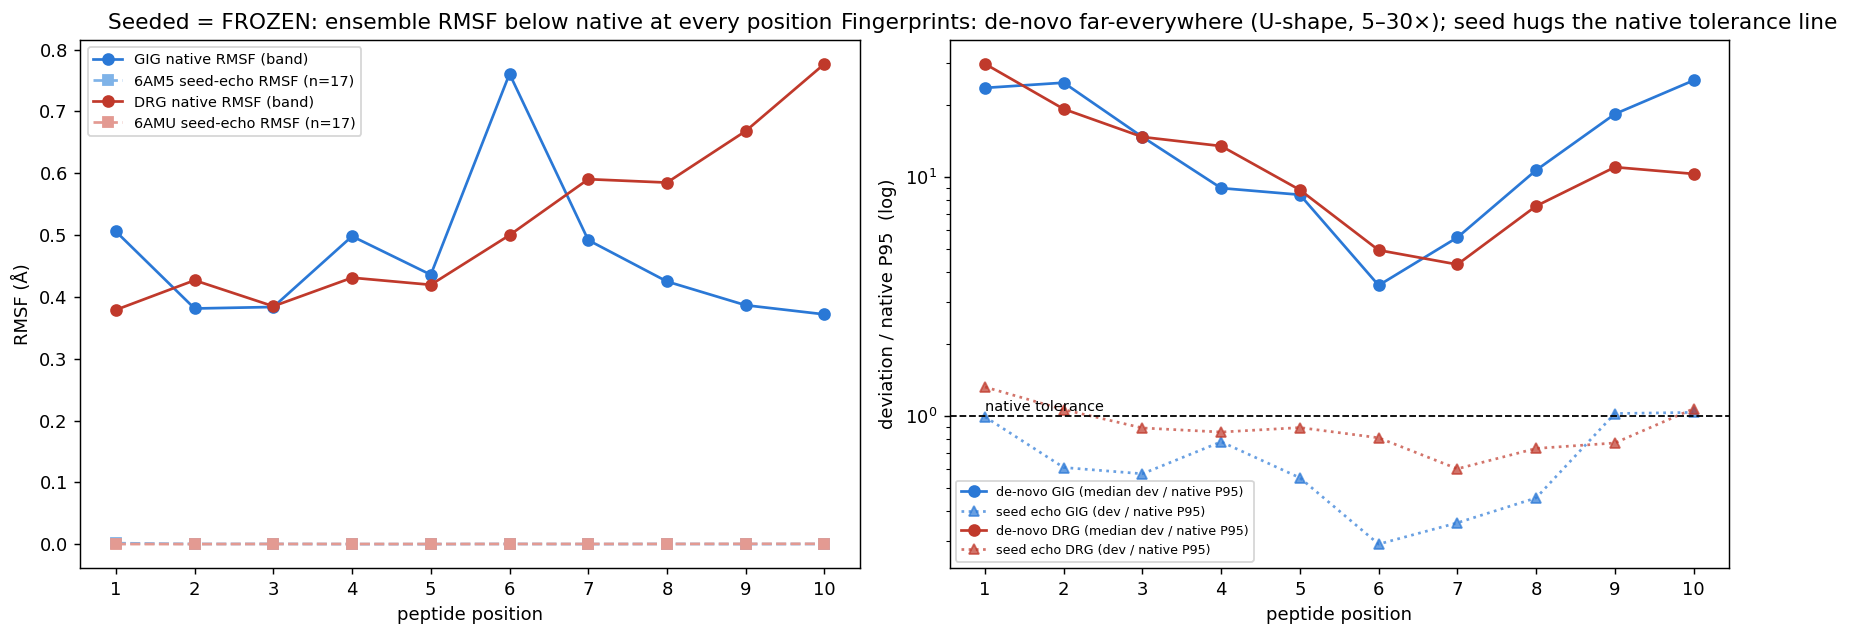

In [6]:
# seeded ensemble (partial-diffusion echoes), per crystal -> ensemble RMSF
seed = {}
for pid in ["6AM5", "6AMU"]:
    pas = [design_pa(f) for f in sorted(glob.glob(f"{ROOT}/outputs/rfdiff_q30/*_split.pdb"))
           if os.path.basename(f).startswith(pid)]
    P = np.array([p for p in pas if p is not None])
    if len(P) >= 3:
        mu = P.mean(0); seed[pid] = dict(rmsf=np.sqrt(((P - mu) ** 2).sum(-1).mean(0)),
                                         dev_from_native=np.linalg.norm(P.mean(0) - REF[pid]["mu"], axis=1), n=len(P))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 5))
# left: seeded 'frozen' — ensemble RMSF vs native band
a1.plot(POS, REF["6AM5"]["rmsf"], "-o", color="#2a78d6", label="GIG native RMSF (band)")
if "6AM5" in seed:
    a1.plot(POS, seed["6AM5"]["rmsf"], "--s", color="#7fb3e8", label=f"6AM5 seed-echo RMSF (n={seed['6AM5']['n']})")
a1.plot(POS, REF["6AMU"]["rmsf"], "-o", color="#c0392b", label="DRG native RMSF (band)")
if "6AMU" in seed:
    a1.plot(POS, seed["6AMU"]["rmsf"], "--s", color="#e39a92", label=f"6AMU seed-echo RMSF (n={seed['6AMU']['n']})")
a1.set_xticks(POS); a1.set_xlabel("peptide position"); a1.set_ylabel("RMSF (Å)")
a1.set_title("Seeded = FROZEN: ensemble RMSF below native at every position"); a1.legend(fontsize=8)
# right: fingerprint — de-novo deviation profile vs seeded deviation profile (both /native P95)
for pid, name, col in [("6AM5", "GIG", "#2a78d6"), ("6AMU", "DRG", "#c0392b")]:
    band = REF[pid]["p95"]
    dn = DES[DES.pid == pid][[f"d{p}" for p in POS]].median().values / band
    a2.plot(POS, dn, "-o", color=col, label=f"de-novo {name} (median dev / native P95)")
    if pid in seed:
        a2.plot(POS, seed[pid]["dev_from_native"] / band, ":^", color=col, alpha=.7,
                label=f"seed echo {name} (dev / native P95)")
a2.axhline(1.0, ls="--", color="k", lw=1); a2.text(1, 1.05, "native tolerance", fontsize=8)
a2.set_xticks(POS); a2.set_xlabel("peptide position"); a2.set_ylabel("deviation / native P95  (log)")
a2.set_yscale("log"); a2.set_title("Fingerprints: de-novo far-everywhere (U-shape, 5–30×); seed hugs the native tolerance line"); a2.legend(fontsize=7)
plt.tight_layout(); plt.savefig(f"{ROOT}/figures/perres_failure_modes.png", dpi=150)
print("saved perres_failure_modes.png"); plt.show()

## Read-out

- **The register is a C-terminal, per-residue event** (native structure). Between-register separation is
  within ~1–2 native RMSF across P1–P4 (register-neutral) and rises to **~8σ at P9 and ~14σ at P10** —
  the anchor the averaged toGIG diluted. Native RMSF confirms these positions are *tight* (≈0.37 Å), so a
  deviation there is real, not thermal.
- **Correction (§3b): the pooled U-shape is a threading-averaging artifact, not a real global failure.**
  Splitting by threading direction (found late in the project — de-novo peptides bury either their
  C-terminal anchor, "forward", like both natives, or their N-terminal anchor, "reverse", at ~50/50
  odds) shows the dramatic U (worst at BOTH termini, ~20-26 Å) appears ONLY in reverse-threaded designs —
  expected, since a mirror-threaded peptide is compared against a native mean built for the opposite
  direction. **Forward-threaded designs alone are much flatter (~3-7 Å across all 10 positions)** — still
  well outside the tight native band (0 % in-band at every position stands), but this is a real,
  register-relevant near-miss, not "placement noise so bad the register question is moot." De-novo
  generation IS trying to seat the peptide correctly roughly half the time; it just isn't precise enough
  to land inside native tolerance anywhere along the backbone. "Seed, don't generate" still holds, but
  the mechanism is precision, not gross mis-placement.
- **Seeded is the opposite fingerprint — near-native but frozen.** Seed echoes sit *at* the native
  tolerance in deviation (~1× P95 everywhere) yet their ensemble RMSF collapses to ≈0, far below the
  native 0.4–0.8 Å band at every position. Same middling *average* as a de-novo near-miss, opposite
  cause: **far-everywhere-U-shaped vs near-native-but-too-still.** The average reports them identically;
  per-residue-vs-native-RMSF is what tells them apart — the whole point of this cut.
- **Honest nuance vs the sequence result.** The noMHC MPNN collapse was at *both* anchors P2 and PΩ
  (sequence identity). Geometry differs at P2: the N-anchor's *position* is shared between registers
  (register-neutral) even though its *identity* isn't recoverable — so the geometric register signal is
  C-terminal only. Sequence-blindness and register-geometry don't co-localize at P2.

See [[md-calibrated-baseline]], [[occupancy-primary-axis]], [[nomhc-recovery-tracks-backbone]],
[[native-md-component-rmsd]].